In [12]:
#%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import seaborn as snb
from typing import NamedTuple
from typing import Tuple

from scipy.stats import binom as binom_dist
from scipy.stats import beta as beta_dist
from scipy.special import beta as beta_fun

snb.set_style('darkgrid')
snb.set(font_scale=1.5)
plt.rcParams['lines.linewidth'] = 3


In [13]:
N = 115
y = 4
Ns = 20
a = 1
b = 1



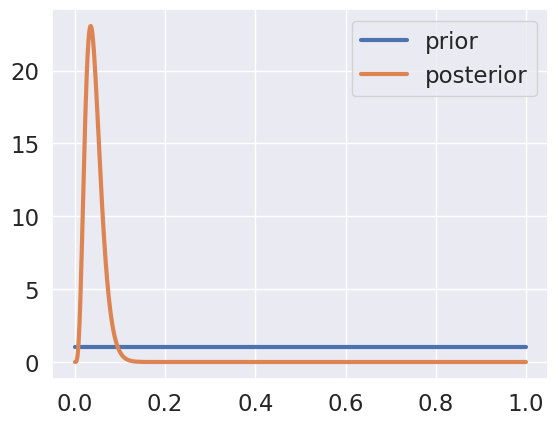

In [14]:
class BetaDistribution(NamedTuple):
    a:  int
    b:  int

    def pdf(self, theta):
        """ returns Beta(theta|a,b) """
        return beta_dist.pdf(theta, a=self.a, b=self.b)
    
    @property
    def mean(self):
        """ returns mean of Beta(a,b)-distribution """
        return self.a/(self.a + self.b)
    
    @property
    def variance(self):
        """ returns variance of Beta(a,b)-distribution """
        return self.a*self.b/(self.a + self.b)**2/(self.a + self.b + 1)
    
    @property
    def mode(self):
        """ returns mode of Beta(a,b)-distribution (assuming it exists) """
        return (self.a - 1)/(self.a+self.b-2)
    
    def get_interval(self, interval_size):
        """ returns a tuple representing a interval_size% credibility interval of Beta(a,b) using scipy.stats.beta.interval  """
        return beta_dist.interval(interval_size/100, a=self.a, b=self.b)
    
    def sample(self, num_samples):
        return beta_dist.rvs(a=self.a, b=self.b, size=num_samples)


prior = BetaDistribution(a=a, b=b)
posterior = BetaDistribution(a=a+y, b=N-y+b)

thetas = jnp.linspace(0, 1, 1000)
# plt.plot(thetas, binom_dist.pmf(y, N, thetas), label = "pmf")
# plt.plot(thetas, beta_dist.pdf(thetas, a, b))
plt.plot(thetas, prior.pdf(thetas), label = "prior")
plt.plot(thetas, posterior.pdf(thetas), label = "posterior")
plt.legend()
plt.show()

In [15]:
thetaMLE = (a+y)/(N-y+b)
print(thetaMLE)
print(thetaMLE + np.array([-1., 1.])*1.96 *np.sqrt((thetaMLE*(1- thetaMLE)/N)))

0.044642857142857144
[0.00689728 0.08238843]


0.5543908502644236


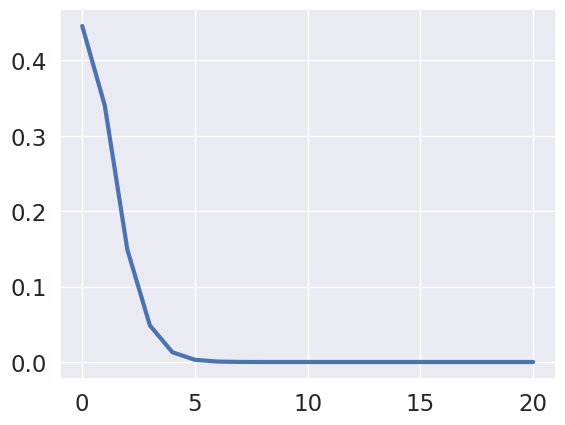

In [16]:
from scipy.special import binom

ys = np.arange(0, Ns +1)

pos = binom(Ns, ys) *beta_fun(ys + y + a, N - y + Ns - ys + b)/beta_fun(y + a, N - y + b)
plt.plot(ys, pos, label = "predictive posterior")

# But what is theta now?
# plt.plot(ys, binom_dist.pmf(pos, N, ), label = "pmf")
print(1 - pos[0])

In [17]:
print(np.sum(pos))
mean = np.sum([k*pos[k] for k in range(len(pos))])
moment = np.sum([(k**2)*pos[k] for k in range(len(pos))])
var = moment - mean**2
print(mean, var)

0.9999999999999999
0.8547008547008544 0.9499152480464955


# Part 3
Poisson Gamma distribution

In [18]:
from scipy.stats import gamma
from scipy.special import loggamma

In [19]:
ys = [7, 4, 8, 11, 12]
N = 5
a0, b0 = 1, 1/10
a = sum(ys) + a0
b = N + b0 

mean_prior = a0/b0
mean_pos = a/b
print(f"{a=}, {b=}, {mean_prior=} {mean_pos=}")

a=43, b=5.1, mean_prior=10.0 mean_pos=8.431372549019608


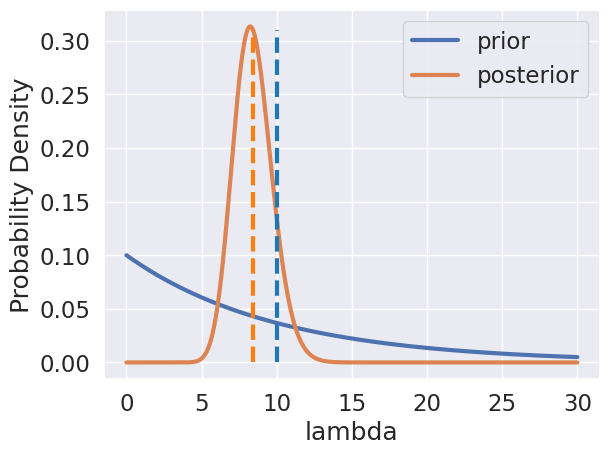

0.9508380442680149 0.9990000333000184


In [20]:
prior = gamma(a = a0, scale = 1/b0)
posterior = gamma(a, scale = 1/b)

lamdas = np.linspace(0.000001, 30, 1000)

plt.plot(lamdas, prior.pdf(lamdas), label = "prior")
plt.plot(lamdas, posterior.pdf(lamdas), label = "posterior")
plt.legend()
plt.xlabel("lambda")
plt.ylabel("Probability Density")
plt.vlines([10, a/b], ymin=0, ymax=0.31, color = ["tab:blue", "tab:orange"], linestyles="dashed")
plt.savefig("figures/gamma_poisson.png", bbox_inches='tight')
plt.show()
print(np.sum(prior.pdf(lamdas)*30/1000), np.sum(posterior.pdf(lamdas)*30/1000))



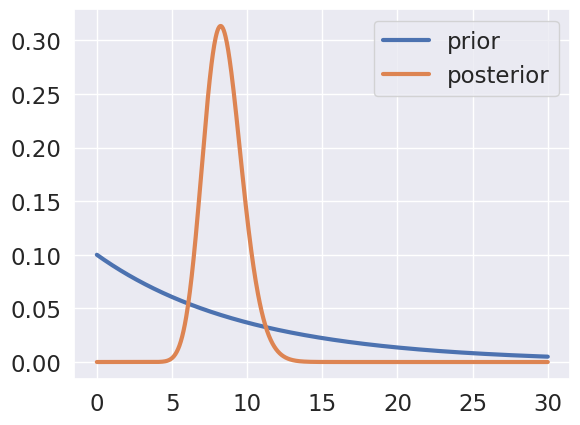

0.950838044268015 0.9990000333000223


In [21]:
class Gamma:
    def __init__(self, a, b) -> None:
        self.a = a
        self.b = b

    def log_pdf(self, lam):
        return (self.a-1)*np.log(lam) - self.b*lam + self.a*np.log(self.b) - loggamma(self.a)
    
    def pdf(self, lam):
        return np.exp(self.log_pdf(lam))

prior = Gamma(a0, b0)
posterior = Gamma(a, b)

plt.plot(lamdas, prior.pdf(lamdas), label = "prior")
plt.plot(lamdas, posterior.pdf(lamdas), label = "posterior")
plt.legend()
plt.show()
print(np.sum(prior.pdf(lamdas)*30/1000), np.sum(posterior.pdf(lamdas)*30/1000))


In [28]:
print([52,38+30+15+8+5, 38+30+15+8+5+22+15+7, 120, 160, 38+25+15+30+8+5, 38+25+15+30+8+5 + 22+15+7+15, 212])
print(np.array([52,38+30+15+8+5, 38+30+15+8+5+22+15+7, 120, 160, 38+25+15+30+8+5, 38+25+15+30+8+5 + 22+15+7+15, 212])*8.6)
print(39*8.6, (52+121)*8.6, 212*8.6)

[52, 96, 140, 120, 160, 121, 180, 212]
[ 447.2  825.6 1204.  1032.  1376.  1040.6 1548.  1823.2]
335.4 1487.8 1823.1999999999998
